In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  
proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
import importlib
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
from ATMS_retrieval import get_eeg_features, ATMS
from util import (load_model_endocer, preprocess_image, generate_eeg, visualize_images, visualize_top_images, plot_similarity_and_mse_with_dual_axis, get_gteeg, save_eeg, load_thingstestimagedata, get_image_path, save_amx_similarities, save_results, 
plot_similarity_range, save_value_function_to_txt)
import torch.nn.functional as F
from torch.utils.data import DataLoader
from diffusion_prior import *
# from custom_pipeline import *
import random
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/Closed_loop_optimizing/experiments/eegdatasets_leaveone.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pic

In [2]:
def initial_policy(image_pool, num_images, history=None):
    """
    在所有图片中随机选择 num_images 张图片
    :param image_pool: [200, 12, 1024] 的图片池
    :param num_images: 选择的图片数量
    :param history: 历史选择过的图片索引
    :return: 选中的图片的类别和图片索引
    """
    total_images = image_pool.view(-1, 1024)  # 展平到 [2400, 1024]
    if history is None:
        history = []

    # 排除已经选择过的图片
    available_indices = [i for i in range(len(total_images)) if i not in history]
    indices = np.random.choice(available_indices, num_images, replace=False)

    # 将索引转换为类别和图片索引
    category_indices = indices // 12  # 每12张图片为一类
    image_indices = indices % 12  # 类别中的图片索引
    return list(zip(category_indices, image_indices))  # 返回 (类别, 图片) 的索引对

def compute_embed_similarity(img_feature, all_features):
    """
    计算某张图片与所有其他图片的余弦相似度
    :param img_feature: 选中图片的特征向量 [1024]
    :param all_features: 所有图片的特征向量 [2400, 1024]
    :return: 余弦相似度 [2400]
    """
    # 计算余弦相似度
    # distances = torch.norm(all_features - img_feature, dim=1)
    # cos_sim = torch.nn.functional.cosine_similarity(img_feature, all_features, dim=1)
    # # cos_sim = F.softmax(cos_sim, dim=0)
    dot_product = torch.matmul(all_features, img_feature)
    # cos_sim = (cos_sim + 1) / 2
    return dot_product


def reward_function(image_path, encoder_model_path, yhat, device, sub):
    """
    生成与某张图片对应的脑电信号，并与 groundtruth 进行相似度计算
    :param image: 图片特征向量 [1024]
    :param groundtruth_eeg: groundtruth 的特征向量 [1024]
    :return: EEG信号与groundtruth的相似度
    """    
    eeg_signal = torch.tensor(get_gteeg(image_path, encoder_model_path, dnn, device))    
    eeg_feature = get_eeg_features(eeg_model, eeg_signal.unsqueeze(0), device, sub)
    similarity = torch.nn.functional.cosine_similarity(eeg_feature, yhat)    
    similarity = (similarity + 1) / 2
    
    # print(similarity)
    return similarity.item(),eeg_feature


def policy_evaluation(policy, image_pool, visited_images, similarities, encoder_model_path, text_list, Probabilities, historical_max_similarity, gamma, history=None):
    """
    评估当前策略的价值（滑动平均更新版本）
    :param policy: 当前策略，用来选择图片
    :param image_pool: 图片特征池 [2400, 1024]
    :param visited_images: 已经展示过的图片列表
    :param similarities: 展示图片与目标图片的相似度列表
    :param gamma: 折扣因子
    :param history: 选择过的图片的历史记录
    :return: 更新后的概率分布 [2400]
    """
    alpha_base = 0.1  # 基础学习率（直接奖励的权重）
    beta_base = 0.05  # 基础学习率（传播奖励的权重）
    epsilon = 1e-6    # 平滑因子

    # 归一化相似度到[-1,1]范围，使得可以表示惩罚和奖励
    if len(similarities) > 0:
        min_sim = min(similarities)
        max_sim = max(similarities)
        # 归一化到[-1,1]，0表示中性（不奖励也不惩罚）
        norm_similarities = [2 * ((s - min_sim) / (max_sim - min_sim + epsilon)) - 1 for s in similarities]
    else:
        norm_similarities = []

    for rank, ((cat, idx), similarity, norm_sim) in enumerate(zip(visited_images, similarities, norm_similarities)):
        img_feature = image_pool[cat * 12 + idx]

        # 动态调整学习率（基于归一化后的相似度，范围[-1,1]）
        # 对于正相似度（奖励）：alpha ∈ [0.5*alpha_base, alpha_base]
        # 对于负相似度（惩罚）：alpha ∈ [0.5*alpha_base, alpha_base]（但方向相反）
        alpha = alpha_base * (0.5 + 0.5 * abs(norm_sim)) * (1 if norm_sim > 0 else -1)
        beta = beta_base * (0.5 + 0.5 * abs(norm_sim)) * (1 if norm_sim > 0 else -1)

        # 更新选中图片的概率（奖励或惩罚）
        if norm_sim > 0:
            # 奖励：增加概率
            Probabilities[cat * 12 + idx] = (1 - abs(alpha)) * Probabilities[cat * 12 + idx] + abs(alpha)
        else:
            # 惩罚：减少概率
            Probabilities[cat * 12 + idx] = (1 - abs(alpha)) * Probabilities[cat * 12 + idx]

        # 计算与所有图片的余弦相似度
        cosine_similarities = compute_embed_similarity(img_feature, image_pool)

        # 更新相似图片的概率（奖励或惩罚）
        for i in range(len(image_pool)):
            if i != cat * 12 + idx:
                reward_to_spread = abs(beta) * cosine_similarities[i].item() * abs(norm_sim)
                if norm_sim > 0:
                    # 奖励：增加概率
                    Probabilities[i] = (1 - reward_to_spread) * Probabilities[i] + reward_to_spread
                else:
                    # 惩罚：减少概率
                    Probabilities[i] = (1 - reward_to_spread) * Probabilities[i]

    # 确保概率非负
    Probabilities = np.maximum(Probabilities, epsilon)
    # 归一化概率分布（确保总和为1）
    Probabilities = Probabilities / (np.sum(Probabilities) + epsilon * len(image_pool))

    return Probabilities

# 策略改进：根据价值函数调整策略
def policy_improvement(value_function, image_pool, iteration=None, save_folder=None,num_images=10, temperature=1.0):
    """
    根据当前价值函数改进策略
    :param value_function: 价值函数
    :param image_pool: 图片特征池 [200, 12, 1024]
    :param num_images: 每轮选择的图片数量
    :return: 改进后的策略函数
    """
    from scipy.special import softmax
    def improved_policy(image_pool, num_images, history= None):
        # total_images = image_pool.view(-1, 1024)  # 展平到 [2400, 1024]
        
        # 排除历史中已经选择过的图片
        if history:
            available_indices = [i for i in range(len(image_pool)) if i not in history]
        else:
            available_indices = np.arange(len(image_pool))
        
        
        scaled_values = value_function[available_indices]
        
        # 基于价值函数为每张图片分配概率
        # 使用 softmax 将价值转化为概率，这样价值高的图片有更大概率被选中
        value_probs = softmax(scaled_values)

        # 打印或保存每轮迭代中的权重
        # if iteration is not None and save_folder is not None:
        #     weight_save_path = os.path.join(save_folder, f"weights_iteration_{iteration}.txt")
        #     with open(weight_save_path, "w") as f:
        #         for idx, prob in zip(available_indices, value_probs):
        #             f.write(f"Image index: {idx}, Probability: {prob}\n")
        #     print(f"Saved weights for iteration {iteration} at {weight_save_path}")

        # 根据分配的概率选择图片
        nominated_images = np.random.choice(available_indices, size=num_images, p=value_probs, replace=False)
        category_indices = nominated_images // 12  # 每12张图片为一类
        image_indices = nominated_images % 12  # 类别中的图片索引
        # print("nominated_images", nominated_images)
        # print("category_indices", category_indices)
        # print("image_indices", image_indices)

        return list(zip(category_indices, image_indices))
    
    return improved_policy





In [3]:
import os
import numpy as np
def set_random_seed(seed):
    """
    设置随机种子以确保实验的可重复性
    :param seed: 要使用的随机种子
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 如果使用GPU
    torch.backends.cudnn.deterministic = True  # 保证每次运行时卷积算法的确定性
    torch.backends.cudnn.benchmark = False  # 保证与随机性无关的优化


In [4]:
# image_folder = '/mnt/dataset0/kyw/closed-loop/image_select'

image_folder = '/mnt/dataset0/jiahua/closed-loop/imageset'
# '/mnt/dataset0/kyw/closed-loop/image_select'#'/mnt/dataset0/ldy/NSD_data/pictures/shared1000'
text_list = sorted(os.listdir(image_folder))
syn_eeg_folder = f'/mnt/dataset0/kyw/closed-loop/results/syn_eeg'
# 过滤掉隐藏文件或其他不需要的文件（如果有）
text_list = [file for file in text_list if not file.startswith('.')]
# text_list

In [5]:

# image_gt_folder = [
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/pheasant/pheasant_18s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/pheasant/pheasant_03s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/aircraft_carrier/aircraft_carrier_09s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/banana/banana_04s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/basil/basil_07s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/basketball/basketball_13s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/bench/bench_01b.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/bench/bench_05s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/bike/bike_15s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/birthday_cake/birthday_cake_15s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/brace/brace_04s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/boat/boat_10s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/cheetah/cheetah_10s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/coconut/coconut_19s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/folder/folder_03s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/glove/glove_12s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/goose/goose_03s.jpg',
# '/mnt/repo0/ldy/3090/Workspace/THINGS/osfstorage/THINGS/Images/images/gorilla/gorilla_12s.jpg']


# image_gt_folder = ['/mnt/dataset0/kyw/closed-loop/gt_image/pheasant_20s.jpg']
# ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00001_aircraft_carrier/aircraft_carrier_22s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00039_cheetah/cheetah_13n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00032_cashew/cashew_15n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00056_crib/crib_16n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00050_cookie/cookie_15s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00056_crib/crib_16n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00188_treadmill/treadmill_16n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00179_taillight/taillight_13s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00171_spoon/spoon_13n.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
# ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg'
# ,'/mnt/dataset0/kyw/closed-loop/gt_image/pheasant_20s.jpg']
# image_gt_path = image_gt_folder[0]
# image_gt_path

image_gt_folder = ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
                        ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
                        , '/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
                        ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
                        ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg']


image_gt_path = image_gt_folder[4]

dir_name = os.path.basename(os.path.dirname(image_gt_path))  # '00014_bike'
gt_category_id = text_list.index(dir_name) 
gt_category_id

32

In [6]:
# features_filename = '/mnt/dataset0/kyw/closed-loop/image_embeddings.pt'
features_filename = '/mnt/dataset0/kyw/closed-loop/image50_embeddings.pt'
# features_filename = '/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/image_embeddings.pt'
# features_filename = '/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/image50_embeddings.pt'
# '/mnt/dataset0/kyw/closed-loop/image_embeddings.pt'
data = torch.load(features_filename, map_location=device)
image_pool = data
image_pool = image_pool.view(-1, 1024)
image_pool = image_pool.detach().cpu()
image_pool.shape

/tmp/ipykernel_2778564/1269073527.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(features_filename, map_location=device)


torch.Size([600, 1024])

In [7]:
dnn = 'alexnet' #'alexnet' #,'cornet_s'
sub = 'sub-01'
# encoder_model_path = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
encoder_model_path = f'/mnt/dataset0/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
gt_eeg_folder = f'/mnt/dataset0/kyw/closed-loop/syn_eeg_gt'
# gt_eeg_folder = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/data/syn_eeg_gt'

In [8]:
# f_encoder =  f"/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
f_encoder =  f"/mnt/dataset0/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
checkpoint = torch.load(f_encoder, map_location=device)

eeg_model = ATMS()  
eeg_model.load_state_dict(checkpoint['eeg_model_state_dict'])


/tmp/ipykernel_2778564/249633920.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f_encoder, map_location=device)


<All keys matched successfully>

In [9]:
seed = 4  # 你可以根据需要更改随机种子
set_random_seed(seed)
max_iterations = 50
gamma = 0.9
num_images= 10

os.makedirs(gt_eeg_folder, exist_ok=True)
gt_eeg_path = os.path.join(gt_eeg_folder, f"gt_{os.path.splitext(os.path.basename(image_gt_path))[0]}.npy")
print(f"gt_eeg_path {gt_eeg_path}")
try:
    synthetic_eeg = torch.from_numpy(np.load(gt_eeg_path))
except:
    synthetic_eeg = torch.tensor(get_gteeg(image_gt_path, encoder_model_path, dnn, device)) 
gt_eeg_path = save_eeg(synthetic_eeg, gt_eeg_folder, file_name=f"gt_{os.path.splitext(os.path.basename(image_gt_path))[0]}.npy" )    

synthetic_eeg.shape

gt_eeg_path /mnt/dataset0/kyw/closed-loop/syn_eeg_gt/gt_pear_13s.npy


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/ldy/Closed_loop_optimizing/experiments/util.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pyto

torch.Size([17, 250])

Created new experiment directory: /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4
Iteration 1...
visited_images [(33, 9), (44, 2), (25, 6), (32, 6), (12, 2), (35, 7), (49, 6), (10, 4), (46, 8), (4, 5)]


/tmp/ipykernel_2778564/4028980391.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  eeg_signal = torch.tensor(get_gteeg(image_path, encoder_model_path, dnn, device))


similarities [0.5123043656349182, 0.5612120032310486, 0.5375553369522095, 0.6180935502052307, 0.4205540716648102, 0.48380565643310547, 0.528501570224762, 0.4849469065666199, 0.6034025549888611, 0.5765318870544434]


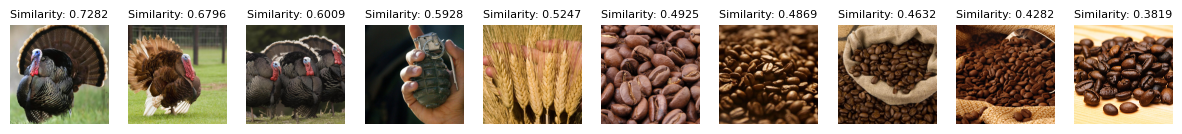

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4/visualization_iteration_0.png
Iteration 2...
visited_images [(5, 1), (49, 8), (40, 5), (0, 9), (12, 10), (42, 11), (10, 10), (9, 2), (2, 3), (4, 10)]
similarities [0.5399476289749146, 0.5067200660705566, 0.45581650733947754, 0.5733421444892883, 0.45578861236572266, 0.6245231032371521, 0.49249011278152466, 0.5227169394493103, 0.5920724868774414, 0.5507349371910095]


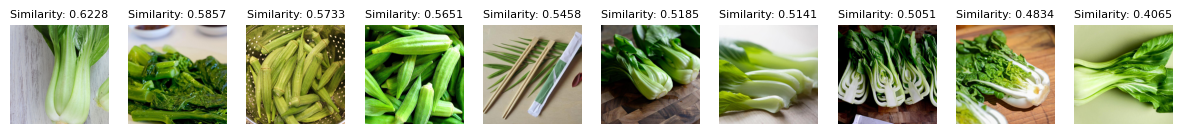

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4/visualization_iteration_1.png
Iteration 3...
visited_images [(24, 2), (2, 4), (44, 7), (19, 11), (12, 8), (40, 11), (43, 7), (33, 3), (43, 0), (1, 8)]
similarities [0.6942106485366821, 0.6285054683685303, 0.4307250380516052, 0.6020278334617615, 0.5060328245162964, 0.4418376088142395, 0.6082228422164917, 0.5531637668609619, 0.42239123582839966, 0.4126715660095215]


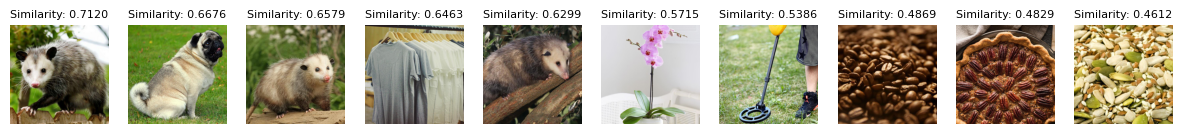

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4/visualization_iteration_2.png
Iteration 4...
visited_images [(5, 6), (11, 8), (38, 3), (6, 3), (17, 7), (35, 6), (32, 7), (38, 5), (2, 8), (49, 1)]
similarities [0.539480447769165, 0.595958948135376, 0.5192484259605408, 0.5401398539543152, 0.5991517901420593, 0.7853183746337891, 0.6063802242279053, 0.5902009010314941, 0.5072425007820129, 0.5480569005012512]


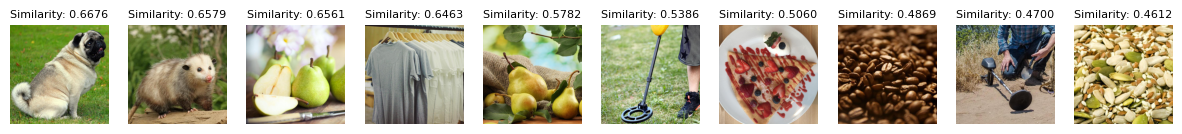

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4/visualization_iteration_3.png
Got it.
Saved to: /home/ldy/Closed_loop_optimizing/plots/Interactive_search/Similarity_and_MSE_Dual_Axis.png


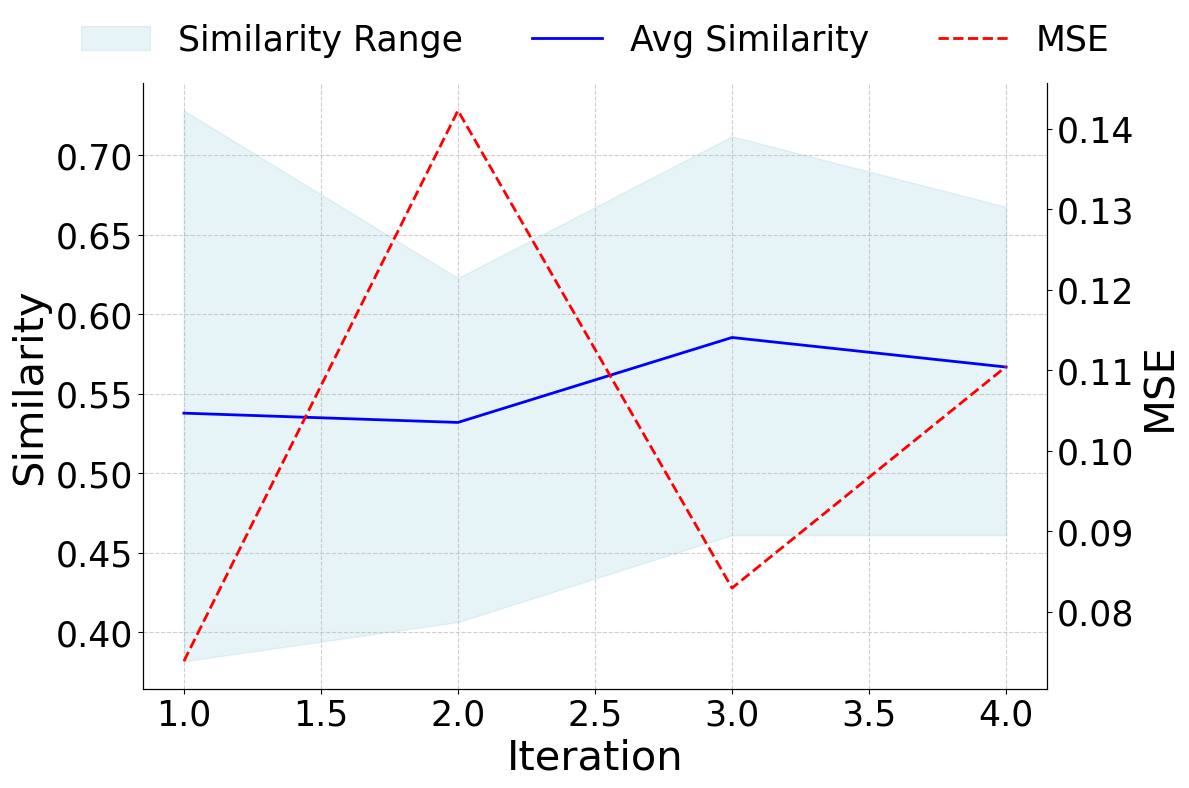

Data saved to /home/ldy/Closed_loop_optimizing/outputs/interactive_search/exp4/00131_pear.json


In [10]:

yhat = get_eeg_features(eeg_model, synthetic_eeg.unsqueeze(0), device, sub)

policy = initial_policy  # 初始随机策略
history = []  # 保存已选图片的历史记录


max_similarities = []  # 保存每次迭代中的最大相似度
historical_max_similarity = -np.inf  # 初始化历史最高相似度
min_similarities = []  # 保存每次迭代中的最小相似度
variances = []  # 保存每次迭代中相似度的方差
scores_per_iteration = []  # 保存每次迭代中每张图片的分数或概率
selected_eegs_per_iteration=[]
similarities_per_iteration = []
loooop_max_similarities = []
save_folder = f'/home/ldy/Closed_loop_optimizing/outputs/interactive_search'
plots_save_folder = '/home/ldy/Closed_loop_optimizing/plots/Interactive_search'

# 确保基础目录存在
os.makedirs(save_folder, exist_ok=True)
# 查找已存在的实验目录
existing_exps = [d for d in os.listdir(save_folder) if d.startswith('exp') and d[3:].isdigit()]
if existing_exps:
    # 获取最大的实验编号
    max_num = max(int(exp[3:]) for exp in existing_exps)
    new_exp_num = max_num + 1
else:
    # 如果没有已存在的实验，从1开始
    new_exp_num = 1
# 创建新实验目录
new_exp_dir = os.path.join(save_folder, f'exp{new_exp_num}')
os.makedirs(new_exp_dir, exist_ok=True)
print(f"Created new experiment directory: {new_exp_dir}")

os.makedirs(save_folder, exist_ok=True)
Probabilities = np.ones(image_pool.shape[0]) / image_pool.shape[0]  # 初始化累积的概率 [1/N]
find_fg = 0
for iteration in range(max_iterations):
    print(f"Iteration {iteration+1}...")
    
    temperature = max(1.0, 2.0 - iteration * 0.1)         

    # 更新历史记录，选择的图片加入历史
    visited_images = policy(image_pool, num_images=num_images, history=history)
    history.extend([cat * 12 + idx for cat, idx in visited_images])  # 记录平面索引
    # 输出选中的图片的实际路径，并可视化
    selected_image_paths = []
    similarities = []
    distances = []
    choose_eeg_features = []
    print(f"visited_images {visited_images}")
    
    # 输出选中的图片的实际路径
    for cat, img in visited_images:        
        image_path = get_image_path(cat, img, text_list)
        selected_image_paths.append(image_path)
        # print(f"Selected image path: {image_path}")
        
        # 计算图片与 groundtruth EEG 信号的相似度
        similarity, choose_eeg_feature = reward_function(image_path, encoder_model_path, yhat, device, sub)
        
        similarities.append(similarity)
        choose_eeg_features.append(choose_eeg_feature)
        
    print(f"similarities {similarities}")
    average_sim = sum(similarities) / len(similarities)
    # print(f"average_sim {average_sim}")
        
    selected_eegs_per_iteration.append(choose_eeg_features)
    
    max_similarity = np.max(similarities)
    min_similarity = np.min(similarities)

    if max_similarity < historical_max_similarity:
        max_similarity = historical_max_similarity  # 保留之前的最高相似度
    else:
        historical_max_similarity = max_similarity  # 更新历史最高相似度
        
    max_similarities.append(max_similarity)
    min_similarities.append(min_similarity)
    
    variance = np.var(similarities)
    variances.append(variance)
        
    # 可视化选中的图片
    # visualize_images(selected_image_paths, similarities, save_folder,iteration)
    # 计算相似度的均值和方差
    # 计算相似度范围

    # variances.append(variance)
    # print(f"Iteration {iteration+1} max_similarity: {max_similarity}")
    # 保存每轮的图片和相似度数据
    
    # save_results(save_folder, iteration+1, selected_image_paths, similarities, max_similarity)
    
    Probabilities = policy_evaluation(policy, image_pool, visited_images, similarities, encoder_model_path, text_list, Probabilities, historical_max_similarity, gamma, history=history)

    # Get indices of top N probabilities (assuming N=1 if not specified)
    N = 10  # You can change this to select more images
    top_indices = np.argsort(Probabilities)[-N:][::-1]  # Get indices sorted by probability (descending)

    # Convert indices to (category, image) pairs
    category_indices = top_indices // 12  # 每12张图片为一类
    image_indices = top_indices % 12  # 类别中的图片索引
    selected_pairs = list(zip(category_indices, image_indices))  # 返回 (类别, 图片) 的索引对

    # Collect all selected image paths
    top_image_paths = []
    top_similaritys = []

    for cat, img in selected_pairs:
        image_path = get_image_path(cat, img, text_list)
        top_image_paths.append(image_path)
        
        similarity, top_eeg_feature = reward_function(image_path, encoder_model_path, yhat, device, sub)
        top_similaritys.append(similarity)
        if gt_category_id==cat:
            find_fg = 1
    # Visualize all selected images
    visualize_top_images(top_image_paths, top_similaritys, new_exp_dir, iteration)        
    similarities_per_iteration.append(top_similaritys)
    # scores_per_iteration.append(Probabilities)
    # save_value_function_to_txt(Probabilities, new_exp_dir,iteration)

    # 策略改进
    new_policy = policy_improvement(Probabilities, image_pool, iteration, new_exp_dir, num_images=num_images, temperature=temperature)

    if find_fg:
        print("Got it.")
        break  # 策略收敛，停止迭代

    policy = new_policy  # 更新策略


import json

def save_similarities_json(similarities, save_folder, filename="similarities.json"):
    os.makedirs(save_folder, exist_ok=True)
    filepath = os.path.join(save_folder, filename)
    with open(filepath, 'w') as f:
        json.dump(similarities, f)
    print(f"Data saved to {filepath}")



# plot_similarity_range(similarities_per_iteration, save_folder)
plot_similarity_and_mse_with_dual_axis(similarities_per_iteration, plots_save_folder, target_similarity=1.0)
save_similarities_json(similarities_per_iteration, new_exp_dir, filename=f"{dir_name}.json")


In [11]:
import numpy as np

def save_stacked_eeg_tensor(selected_eegs_per_iteration, save_folder, filename="stacked_eeg_features.pt"):
    """
    Stack EEG features from a list into a PyTorch tensor and save as a .pt file.
    
    Args:
        selected_eegs_per_iteration (list): List of EEG feature tensors/arrays.
        save_folder (str): Directory where the file will be saved.
        filename (str): Name of the output file (default: "stacked_eeg_features.pt").
    
    Returns:
        torch.Tensor: The stacked tensor (shape: [num_iterations, ...]).
    """
    stacked_per_iter = [
        torch.stack(sub_list, dim=0)  # 假设 sub_list 是 [tensor1, tensor2, ...]
        for sub_list in selected_eegs_per_iteration
    ]
    stacked_eegs = torch.stack(stacked_per_iter, dim=0)  # shape: [num_iterations, ...]

    # Ensure the save directory exists
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, filename)
    
    # Save the tensor
    torch.save(stacked_eegs, save_path)
    print(f"Stacked EEG features saved to {save_path} (shape: {stacked_eegs.shape})")
    
    return stacked_eegs



In [12]:
stacked_eegs = save_stacked_eeg_tensor(selected_eegs_per_iteration, plots_save_folder, filename=f'{dir_name}.pt')

Stacked EEG features saved to /home/ldy/Closed_loop_optimizing/plots/Interactive_search/00131_pear.pt (shape: torch.Size([4, 10, 1, 1024]))


In [13]:
stacked_eegs.shape

torch.Size([4, 10, 1, 1024])